In [1]:
import numpy as np
import pandas as pd
from scipy.stats import multivariate_normal, multinomial, poisson

from matplotlib import cm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid')

np.random.seed(0)

In [2]:
# Import data
df_pop = pd.read_csv('../data/germany-population-2011.csv')

In [3]:
N = 30
x = np.array([[i, j] for i in range(N) for j in range(N)])

In [4]:
def generate_probability_matrix(A: int = 30, delta: float = 1) -> np.ndarray:
  X = np.arange(0, A, delta)
  Y = np.arange(0, A, delta)
  G = np.array([[i, j] for i in X for j in Y])
  p_main = multivariate_normal.pdf(G, mean=[15, 15], cov=[[90, 90*0.98], [90*0.98, 90]])
  p_sub1 = multivariate_normal.pdf(G, mean=[20, 5], cov=[[90, 90*0.95], [90*0.95, 90]])
  p_sub2 = multivariate_normal.pdf(G, mean=[5, 20], cov=[[90, 90*0.95], [90*0.95, 90]])

  p = (p_main + p_sub1 + p_sub2) / 3
  p = p / p.sum() # Re-normalise

  return p

In [5]:
df_pop_subset = df_pop[(df_pop['gender'] == 'Male') & (df_pop['age'] < 30)]
prop = df_pop_subset['pop'].values / df_pop_subset['pop'].sum()

n = multinomial.rvs(n=5e3, p=prop)
P = df_pop_subset['pop'].values

In [6]:
A = 30
cnt_prob = generate_probability_matrix(A)
coords = np.array([[i,j] for i in range(30) for j in range (30)])
rate = P[coords[:,0]] / P[coords[:,1]] * cnt_prob           # True contact rate
sample_cint = (rate.reshape(A, A) * n[:,np.newaxis]).ravel()

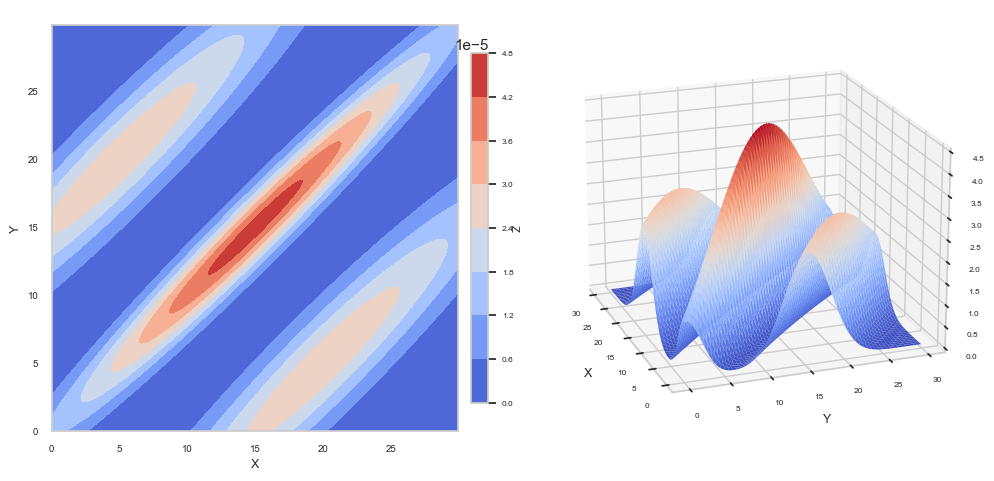

In [7]:
fig = plt.figure(figsize=(10, 5))

X = np.arange(0, 30, 0.1)
Y = np.arange(0, 30, 0.1)
X, Y = np.meshgrid(X, Y)
Z = generate_probability_matrix(30, 0.1).reshape(X.shape[0], Y.shape[0])

ax1 = fig.add_subplot(121)
cs = ax1.contourf(X, Y, Z, cmap='coolwarm')
ax1.set_aspect('equal')
ax1.set_xlabel('X', fontsize=9)
ax1.set_ylabel('Y', fontsize=9)
cbar = fig.colorbar(cs, fraction=0.04, pad=0.03)
cbar.set_label('Z', fontsize=8, rotation=-90)
cbar.ax.tick_params(labelsize=6)

# Reduce fontsize of ticks for ax1
ax1.tick_params(axis='both', which='major', labelsize=7)

ax2 = fig.add_subplot(122, projection='3d')
cs = ax2.plot_surface(X, Y, Z, cmap='coolwarm', lw=0, rstride=5, cstride=5)
ax2.invert_xaxis()
ax2.view_init(elev=20, azim=-20, roll=0)
ax2.set_xlabel('X', fontsize=9)
ax2.set_ylabel('Y', fontsize=9)

# Reduce fontsize of ticks for ax2
ax2.tick_params(axis='x', which='major', labelsize=6)
ax2.tick_params(axis='y', which='major', labelsize=6)
ax2.tick_params(axis='z', which='major', labelsize=6)

plt.tight_layout()
plt.show()

In [8]:
# Generate random data
C = 10
y = poisson.rvs(mu=C*sample_cint)

In [9]:
df = pd.DataFrame({
  'y': y,
  'age_part': coords[:,0],
  'age_cnt': coords[:,1]
})

df['n'] = n[df['age_part']]
df['p'] = P[df['age_cnt']]

In [10]:
df.to_csv('../data/sim/test.csv', index=False)

In [11]:
def delta2(a, intercept=1/2, slope=1/29):
  return intercept + slope * a

def delta1(a, intercept=3/2, slope=1/29):
  return intercept - (1/2 + slope * a)/2

# Sanity check
assert delta2(29) < 3
assert delta2(0) > 0
assert delta1(29) < 3/2
assert delta1(0) > 0

In [12]:
C = 10
aid = coords[:,0]

y0 = poisson.rvs(mu=delta1(aid)*C*sample_cint)
y1 = poisson.rvs(mu=delta2(aid)*C*sample_cint)

N0 = n[aid]
N1 = N0
P0 = np.round(2/3 * P[aid])
P1 = np.round(1/3 * P[aid])

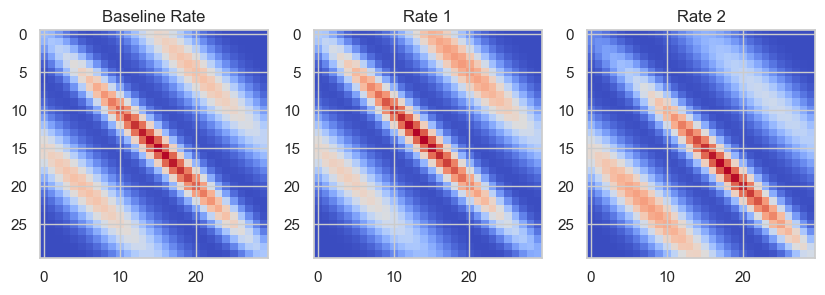

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

rate1 = delta1(aid)*cnt_prob
rate2 = delta2(aid)*cnt_prob

ax[0].imshow(cnt_prob.reshape(A, A), cmap='coolwarm')
ax[1].imshow(rate1.reshape(A, A), cmap='coolwarm')
ax[2].imshow(rate2.reshape(A, A), cmap='coolwarm')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[2].set_aspect('equal')

ax[0].set_title('Baseline Rate')
ax[1].set_title('Rate 1')
ax[2].set_title('Rate 2')

plt.show()

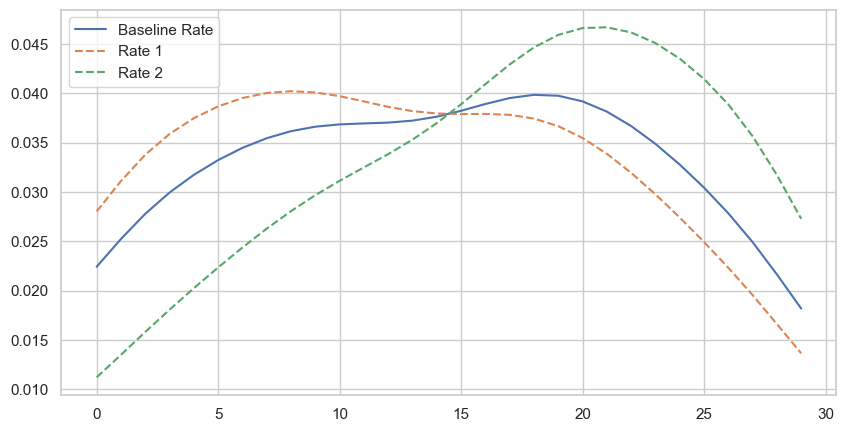

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

rate1 = delta1(aid)*cnt_prob
rate2 = delta2(aid)*cnt_prob

ax.plot(cnt_prob.reshape(A, A).sum(axis=1), label='Baseline Rate')
ax.plot(rate1.reshape(A, A).sum(axis=1), label='Rate 1', linestyle='--')
ax.plot(rate2.reshape(A, A).sum(axis=1), label='Rate 2', linestyle='--')
ax.legend()

plt.show()

In [15]:
df = pd.DataFrame({
  'y': np.concatenate([y0, y1]),
  'age_part': np.concatenate([coords[:,0], coords[:,0]]),
  'age_cnt': np.concatenate([coords[:,1], coords[:,1]]),
  'X': np.concatenate([np.zeros(A**2), np.ones(A**2)]),
  'n': np.concatenate([N0, N1]),
  'p': np.concatenate([P0, P1])
})

# Export data
df.to_csv('../data/sim/test2.csv', index=False)